In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Correlation section


In [2]:
ener_corr = np.loadtxt('../resources/ener_corr.txt')

FileNotFoundError: ../resources/ener_corr.txt not found.

In [ ]:
ener_corr.shape

In [ ]:
print(ener_corr[50])

In [ ]:
plt.plot(ener_corr[50])

In [ ]:
def get_autocorrelation_function(signal : np.ndarray, norm : bool = True, mean : bool = True) -> np.ndarray:
    """
    Computes the autocorrelation function of a signal.

    Parameters
    ----------
    signal : np.ndarray
        Statistical signal to be autocorrelated.

    norm : bool
        Whether to compute normalized or unnormalized autocorrelation function.
        Default True.

    mean : np.ndarray
        Whether to subtract the mean from the signal.
        Default True.

    Returns
    -------
    autocorrelation_function : np.ndarray
        Autocorrelation function of the signal

    """

    #computing the lenght of the vectors
    M = len(signal)

    work_signal = signal.copy()
    if mean:
        work_signal -= np.mean(work_signal)

    #computing correlation
    autocorrelation_function = np.correlate(work_signal, work_signal, mode="full")[-M:]
    autocorrelation_function /= np.arange(M, 0, -1)

    #normalizing the autocorrelation function
    if norm:
        autocorrelation_function /= np.var(work_signal)
       
    return autocorrelation_function

In [ ]:
corr = np.zeros((10000,5000))
for i in range(ener_corr.shape[0]) :
	corr[i] = get_autocorrelation_function(ener_corr[i,:5000], norm=True, mean=False)

avg_corr = np.mean(corr, axis=0)

In [ ]:
corr_no_mean = np.zeros(ener_corr.shape)
for i in range(1000) :
	corr_no_mean[i] = get_autocorrelation_function(ener_corr[i], norm=True, mean=False)

avg_corr_no_mean = np.mean(corr_no_mean, axis=0)

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(ener_corr[0])
plt.plot(ener_corr[100])
plt.xlim(4500,5000)

In [ ]:
plt.plot(corr[0], label='corr 0')
plt.plot(corr[1], label='corr 1')

plt.plot(corr[50], label='corr 50')
plt.plot(corr[100], label='corr 100')

plt.legend()

In [ ]:
plt.plot(avg_corr)
plt.axhline(0, color='black', lw=1)

In [ ]:
diffusion_steps=10


for t in range(diffusion_steps - 1, 0, -1):
	print(f"{t} ; {diffusion_steps-t}")

# Animation view

In [3]:
from IPython.display import HTML, display

def display_synced_gifs(gif_paths, width=400):
    paths_js = ','.join([f'"{p}"' for p in gif_paths])
    n = len(gif_paths)
    html = f"""
    <div style="display: flex; gap: 10px;">
        {''.join([f'<img id="gif{i}" width="{width}">' for i in range(n)])}
    </div>
    <script>
        (function() {{
            const paths = [{paths_js}];
            const gifs = paths.map((src, i) => document.getElementById("gif" + i));

            function fetchDuration(url) {{
                return fetch(url)
                    .then(r => r.arrayBuffer())
                    .then(buf => {{
                        const dv = new DataView(buf);
                        let pos = 0, duration = 0;
                        while (pos < dv.byteLength - 10) {{
                            if (dv.getUint8(pos) === 0x21 && dv.getUint8(pos + 1) === 0xF9) {{
                                duration += 10 * dv.getUint16(pos + 4, true);
                            }}
                            pos++;
                        }}
                        return duration;
                    }});
            }}

            Promise.all(paths.map(fetchDuration)).then(durations => {{
                const maxDuration = Math.max(...durations);
                const reload = () => {{
                    gifs.forEach((gif, i) => {{
                        gif.src = paths[i] + "?t=" + Date.now();
                    }});
                }};
                reload();
                setInterval(reload, maxDuration);
            }});
        }})();
    </script>
    """
    display(HTML(html))

In [4]:
diff_steps = [50, 200, 1000]
paths = [f"../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds{step}.gif" for step in diff_steps]
display_synced_gifs(paths)

<table>
  <tr>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds50.gif" alt="anim diff_steps = 50"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds200.gif" alt="anim diff_steps = 200"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.5_ds1000.gif" alt="anim diff_steps = 1000"></td>
  </tr>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.5_ds50.png" alt="img diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.5_ds200.png" alt="img diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.5_ds1000.png" alt="img diff_steps = 1000"></td>
</table>

<table>
  <tr>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.2_ds50.gif" alt="anim diff_steps = 50"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.2_ds200.gif" alt="anim diff_steps = 200"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.2_ds1000.gif" alt="anim diff_steps = 1000"></td>
  </tr>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.2_ds50.png" alt="img diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.2_ds200.png" alt="img diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.2_ds1000.png" alt="img diff_steps = 1000"></td>
</table>

<table>
  <tr>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.01_ds50.gif" alt="anim diff_steps = 50"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.01_ds200.gif" alt="anim diff_steps = 200"></td>
    <td><img src="../resources/sampling_results/conditioning/smpl_anim_u=0.01_ds1000.gif" alt="anim diff_steps = 1000"></td>
  </tr>
  <tr>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.01_ds50.png" alt="img diff_steps = 50"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.01_ds200.png" alt="img diff_steps = 200"></td>
	<td><img src="../resources/sampling_results/conditioning/smpl_img_u=0.01_ds1000.png" alt="img diff_steps = 1000"></td>
</table>

<table>
  <tr>
    <td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.37_ds50.gif" alt="anim diff_steps = 50"></td>
    <td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.37_ds200.gif" alt="anim diff_steps = 200"></td>
    <td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.37_ds1000.gif" alt="anim diff_steps = 1000"></td>
</table>

<table>
  <tr>
    <td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.38_ds50.gif" alt="anim diff_steps = 50"></td>
    <td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.38_ds200.gif" alt="anim diff_steps = 200"></td>
    <td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.38_ds1000.gif" alt="anim diff_steps = 1000"></td>
</table>

<table>
  <tr>
    <td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.10_ds50.gif" alt="anim diff_steps = 50"></td>
    <td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.10_ds200.gif" alt="anim diff_steps = 200"></td>
    <td><img src="../resources/sampling_results/conditioning/histograms/histo_anim_u=0.10_ds1000.gif" alt="anim diff_steps = 1000"></td>
</table>

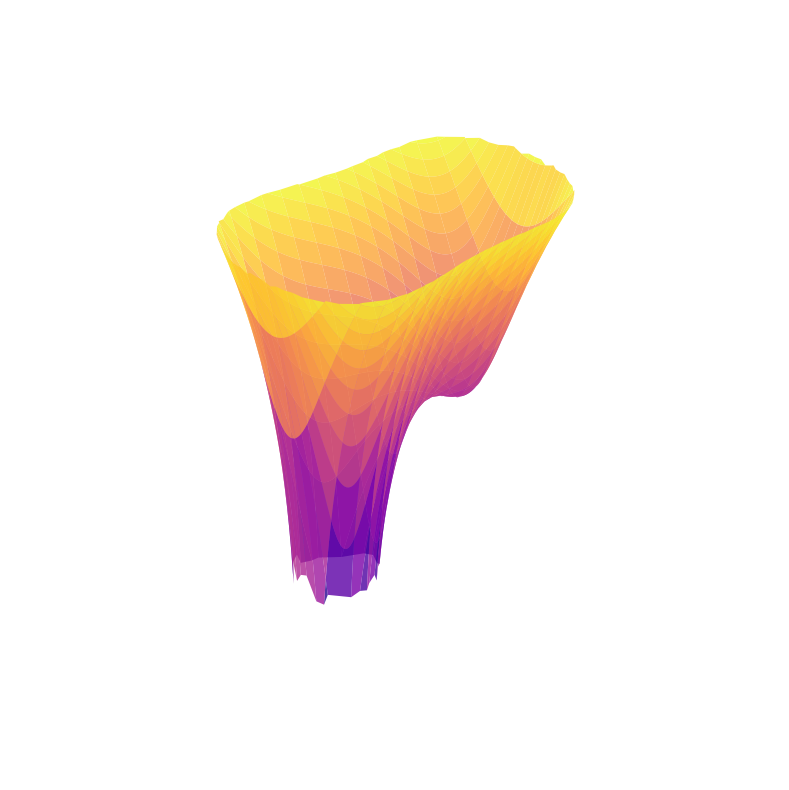

In [5]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Model parameters
eps = 3.0
c = 1.0
d = 0.5

def energy(x):
    if len(x.shape) < 2:
        return eps * (c * (x[0]**2 - 1)**2 + (x[0] - x[1])**2 + d * (x[0] + x[1]))
    else:
        return eps * (c * (x[:, 0]**2 - 1)**2 + (x[:, 0] - x[:, 1])**2 + d * (x[:, 0] + x[:, 1]))

# Grid range - reduced resolution for better performance
pos_min, pos_max = -6, 6
x_vals = torch.linspace(pos_min, pos_max, 600)  # Reduced from 1000 to 200
y_vals = torch.linspace(pos_min, pos_max, 600)
X, Y = torch.meshgrid(x_vals, y_vals, indexing='ij')
points = torch.stack([X.flatten(), Y.flatten()], dim=1)

Z = energy(points).reshape(X.shape)

# Define the energy range you want to visualize
min_energy = 0
max_energy = 30

# Create mask for points within energy range
energy_mask = (Z >= min_energy) & (Z <= max_energy)

# Apply mask to coordinates and energy values
X_masked = torch.where(energy_mask, X, torch.nan)
Y_masked = torch.where(energy_mask, Y, torch.nan)
Z_masked = torch.where(energy_mask, Z, torch.nan)


# Apply logarithmic scaling to handle large energy values
Z_log_masked = torch.where(energy_mask, torch.log10(Z_masked + 1), torch.nan)

# Create the plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface with masked values (NaN values won't be plotted)
surf = ax.plot_surface(X_masked.numpy(), Y_masked.numpy(), Z_log_masked.numpy(), 
                      cmap='plasma', alpha=0.8, edgecolor='none')

# Remove axes completely
ax.set_axis_off()

# Remove background panes and grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('none')
ax.yaxis.pane.set_edgecolor('none')
ax.zaxis.pane.set_edgecolor('none')

# Remove grid
ax.grid(False)

# Set transparent background for the figure
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Improve viewing angle
ax.view_init(elev=20, azim=240)

plt.tight_layout()

# Save with transparent background
plt.savefig('../resources/presentation/energy_surface.png', 
           transparent=True,           # Transparent background
           bbox_inches='tight',        # Remove extra whitespace
           pad_inches=0,              # No padding
           dpi=300)                   # High resolution

plt.show()

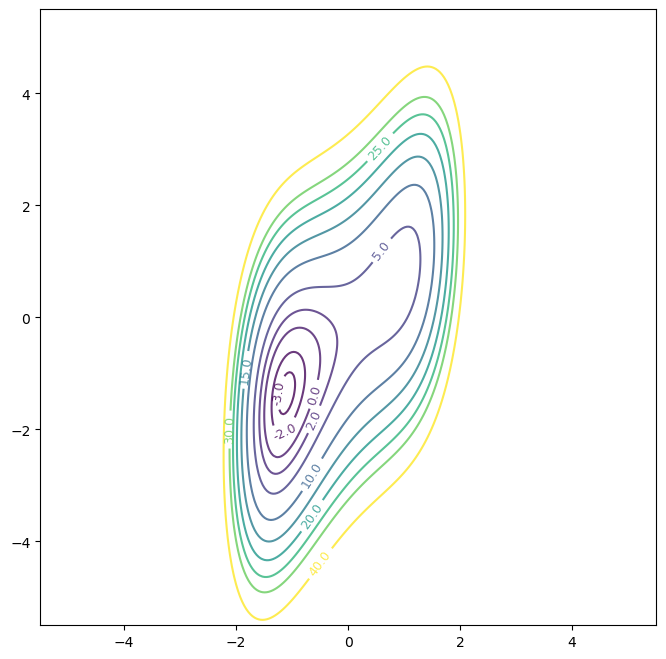

In [6]:
# Contour plotting function
def plot_contour_lines_only(output_dir, energy_levels=None, colors=None, 
                           linewidths=None, linestyles=None, alpha=0.8):
    """
    Plot specific contour lines only (no filled regions)
    
    Parameters:
    -----------
    output_dir : str
        Output directory and filename (without extension)
    energy_levels : list
        Specific energy levels to plot as contours
    colors : list or str
        Colors for each contour level
    linewidths : list or float
        Line widths for contours
    linestyles : list or str
        Line styles for contours
    alpha : float
        Transparency of contour lines
    """
    # Default energy levels if not provided
    if energy_levels is None:
        energy_levels = [-3, -2, 0, 2, 5, 10, 15, 20, 25, 30, 40]
    
    # Define grid for visualization
    upper_lim, lower_lim = 5.5, -5.5
    x = np.linspace(lower_lim, upper_lim, 300)
    y = np.linspace(lower_lim, upper_lim, 300)
    X, Y = np.meshgrid(x, y)

    # Compute energy landscape
    Z_target = np.zeros([len(X), len(Y)])
    for i in range(len(X)):
        for j in range(len(Y)):
            conf = torch.tensor([X[i][j], Y[i][j]], dtype=torch.float32)
            Z_target[i, j] = energy(conf).item()

    # Create figure
    fig, ax = plt.subplots(figsize=(8, 8), dpi=100)

    # Set plot limits
    ax.set_xlim(lower_lim, upper_lim)
    ax.set_ylim(lower_lim, upper_lim)

    # Plot contour lines only
    contour = ax.contour(X, Y, Z_target, levels=energy_levels, 
                        colors=colors, alpha=alpha, 
                        linewidths=linewidths or 1.5,
                        linestyles=linestyles or '-')
    
    # Add contour labels
    ax.clabel(contour, inline=True, fontsize=9, fmt='%.1f')
    
    # Set labels
    #ax.set_xlabel('x', fontsize=12)
    #ax.set_ylabel('y', fontsize=12)
    #ax.set_title('Energy Contour Lines', fontsize=14)
    
    # Equal aspect ratio
    ax.set_aspect('equal')
    
    # Add grid for reference
    #ax.grid(True, alpha=0.3)
    
    # Save and close
    plt.savefig(output_dir + ".png", dpi=300, bbox_inches='tight')
    plt.show()  # Show instead of close for notebook

# Usage examples:
# Basic contour plot
plot_contour_lines_only("../resources/presentation/energy_contours")

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

def load_energy_data(data_dir):
    """
    Load energy vs time and energy vs calls data from DAT files
    
    Parameters:
    -----------
    data_dir : str
        Directory containing the DAT files
        
    Returns:
    --------
    time_data : dict
        Dictionary with keys: 'step', 'time', 'energy', 'acceptance', 'dx'
    calls_data : dict  
        Dictionary with keys: 'step', 'calls', 'energy'
    """
    
    # Find the most recent energy vs time file
    time_files = glob.glob(os.path.join(data_dir, "energy_vs_time_*.dat"))
    if not time_files:
        raise FileNotFoundError(f"No energy_vs_time files found in {data_dir}")
    
    time_file = max(time_files, key=os.path.getctime)  # Most recent file
    print(f"Loading time data from: {time_file}")
    
    # Load energy vs time data
    time_data_raw = np.loadtxt(time_file)
    time_data = {
        'step': time_data_raw[:, 0],
        'time': time_data_raw[:, 1], 
        'energy': time_data_raw[:, 2],
        'acceptance': time_data_raw[:, 3],
        'dx': time_data_raw[:, 4]
    }
    
    # Find the most recent energy vs calls file
    calls_files = glob.glob(os.path.join(data_dir, "energy_vs_calls_*.dat"))
    if not calls_files:
        raise FileNotFoundError(f"No energy_vs_calls files found in {data_dir}")
    
    calls_file = max(calls_files, key=os.path.getctime)  # Most recent file
    print(f"Loading calls data from: {calls_file}")
    
    # Load energy vs calls data
    calls_data_raw = np.loadtxt(calls_file)
    calls_data = {
        'step': calls_data_raw[:, 0],
        'calls': calls_data_raw[:, 1],
        'energy': calls_data_raw[:, 2]
    }
    
    return time_data, calls_data

def plot_energy_vs_time(time_data, save_path=None):
    """
    Plot energy vs time with secondary axis for acceptance ratio - scatter only
    """
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Scatter plot for energy vs time
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    scatter1 = ax1.scatter(time_data['time'], time_data['energy'], color='tab:red', s=0.5, alpha=0.8, label='Energy')
    ax1.grid(True, alpha=0.3)
    
    # Create secondary y-axis for acceptance ratio
    ax2 = ax1.twinx()
    ax2.set_ylabel('Acceptance Ratio', fontsize=12)
    scatter2 = ax2.scatter(time_data['time'], time_data['acceptance'], color='tab:blue', s=0.2, alpha=0.7, label='Acceptance Ratio')
    ax2.set_ylim(0, 1)
    
    # Add legend
    ax1.legend([scatter1, scatter2], ['Energy', 'Acceptance Ratio'], loc='upper right')
    
    plt.title('Energy Evolution vs Time', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved energy vs time plot to: {save_path}")
    
    plt.show()

def plot_energy_vs_calls(calls_data, save_path=None):
    """
    Plot energy vs number of function calls - scatter only
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Scatter plot for energy vs calls
    ax.scatter(calls_data['calls'], calls_data['energy'], color='tab:green', s=0.5, alpha=0.8, label='Energy')
    ax.set_xlabel('Total Energy Function Calls', fontsize=12)
    ax.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Format x-axis to show calls in scientific notation if large
    if calls_data['calls'].max() > 1e6:
        ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
    
    plt.title('Energy Evolution vs Function Calls', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved energy vs calls plot to: {save_path}")
    
    plt.show()

def plot_both_comparisons(time_data, calls_data, save_path=None):
    """
    Plot both comparisons in a single figure with subplots
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left plot: Energy vs Time
    color = 'tab:red'
    ax1.scatter(time_data['time'], time_data['energy'], color=color, s=0.3)
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    ax1.tick_params(axis='y')
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Energy vs Time', fontsize=14, fontweight='bold')
    
    # Right plot: Energy vs Calls
    color = 'tab:green'
    ax2.scatter(calls_data['calls'], calls_data['energy'], color=color, s=0.3)
    ax2.set_xlabel('Total Energy Function Calls', fontsize=12)
    ax2.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    ax2.tick_params(axis='y')
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Energy vs Function Calls', fontsize=14, fontweight='bold')
    
    # Format x-axis for calls if large numbers
    if calls_data['calls'].max() > 1e6:
        ax2.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved comparison plots to: {save_path}")
    
    plt.show()

Loading time data from: ../resources/nested_sampling_configs/energy_vs_time_20250617_104841.dat
Loading calls data from: ../resources/nested_sampling_configs/energy_vs_calls_20250617_104841.dat
Saved energy vs time plot to: ../resources/presentation/energy_vs_time.png


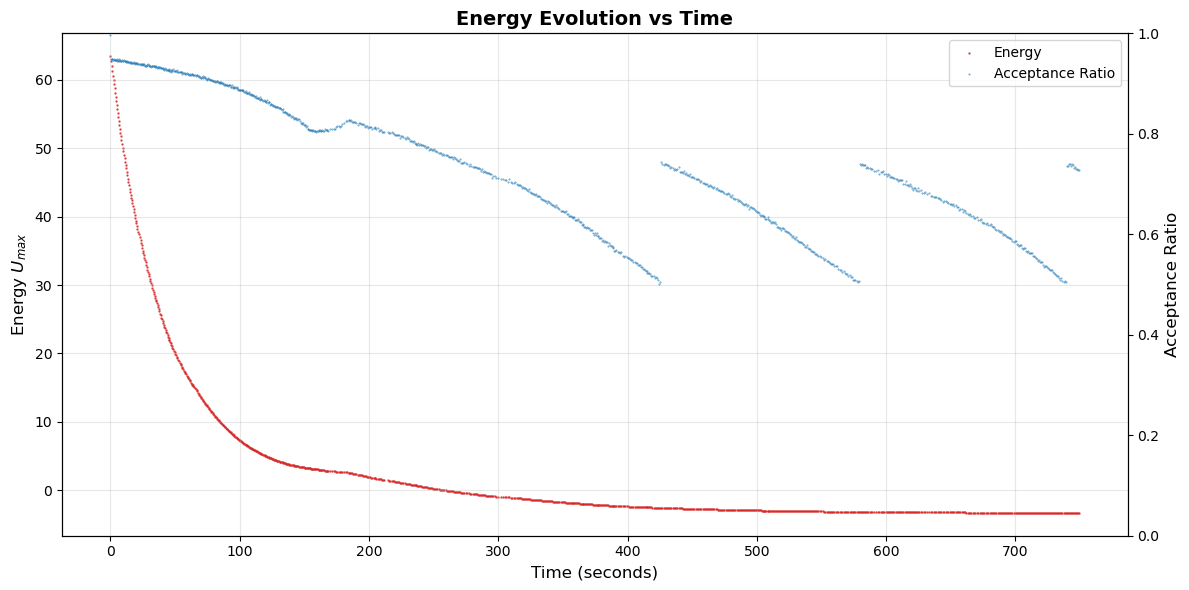

Saved energy vs calls plot to: ../resources/presentation/energy_vs_calls.png


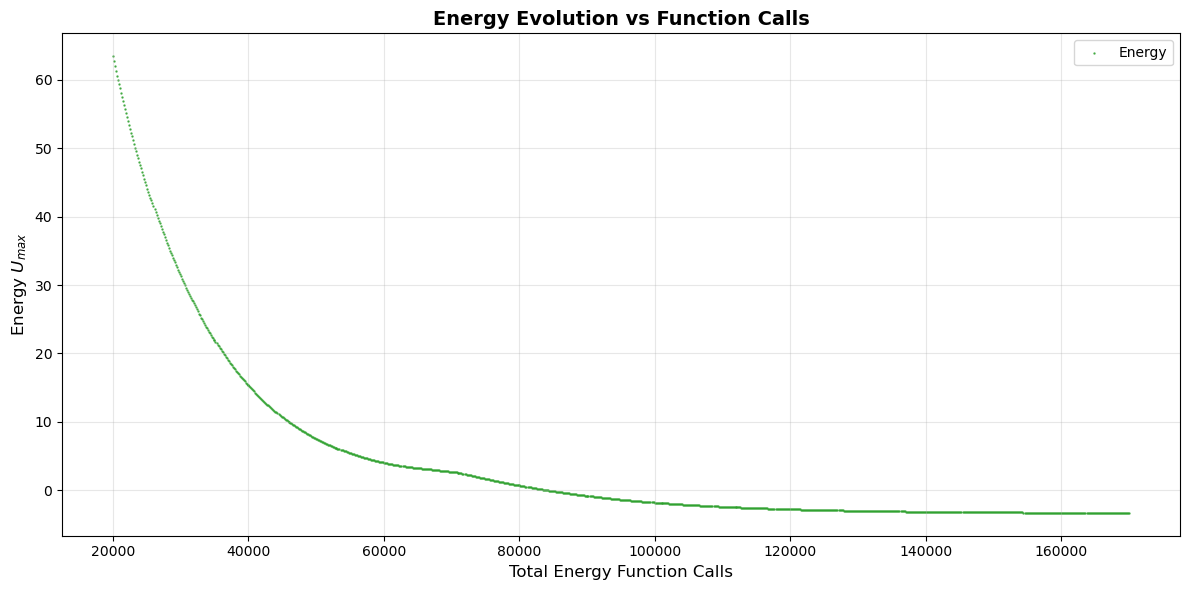

Saved comparison plots to: ../resources/presentation/energy_comparison.png


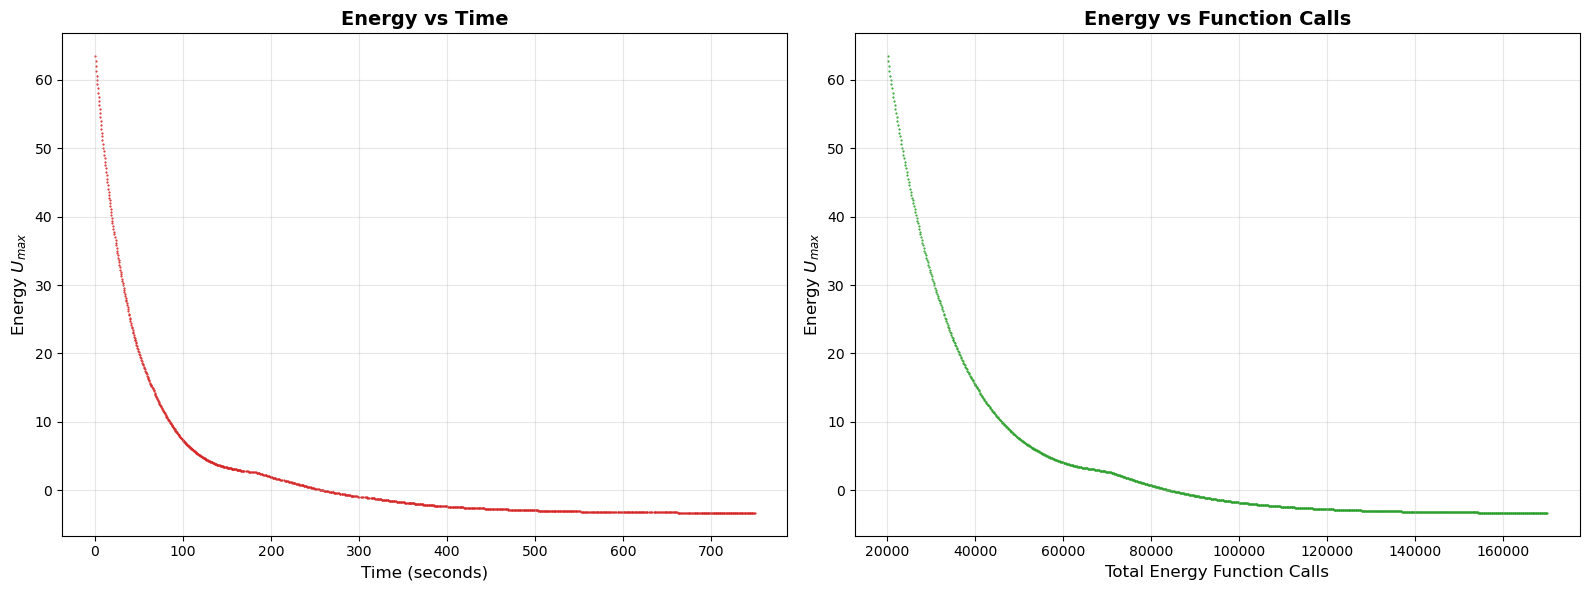


Data Summary:
Total runtime: 749.40 seconds (12.49 minutes)
Total energy calls: 170000
Initial energy: 63.49
Final energy: -3.31
Energy reduction: 66.80


In [8]:

# Set the directory containing your DAT files
data_directory = "../resources/nested_sampling_configs/"

try:
    # Load the data
    time_data, calls_data = load_energy_data(data_directory)
    
    # Plot separately
    plot_energy_vs_time(time_data, save_path="../resources/presentation/energy_vs_time.png")
    plot_energy_vs_calls(calls_data, save_path="../resources/presentation/energy_vs_calls.png")
    
    # Plot both together
    plot_both_comparisons(time_data, calls_data, save_path="../resources/presentation/energy_comparison.png")
    
    # Print some statistics
    print(f"\nData Summary:")
    print(f"Total runtime: {time_data['time'][-1]:.2f} seconds ({time_data['time'][-1]/60:.2f} minutes)")
    print(f"Total energy calls: {calls_data['calls'][-1]:.0f}")
    print(f"Initial energy: {time_data['energy'][0]:.2f}")
    print(f"Final energy: {time_data['energy'][-1]:.2f}")
    print(f"Energy reduction: {time_data['energy'][0] - time_data['energy'][-1]:.2f}")
    
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Make sure you have run the nested sampling algorithm first to generate the data files.")

In [43]:
def load_energy_data(data_dir, algorithm_name=""):
    """
    Load energy vs time and energy vs calls data from DAT files
    
    Parameters:
    -----------
    data_dir : str
        Directory containing the DAT files
    algorithm_name : str
        Name for logging purposes
        
    Returns:
    --------
    time_data : dict
        Dictionary with keys: 'step', 'time', 'energy', 'acceptance', 'dx'
    calls_data : dict  
        Dictionary with keys: 'step', 'sampl_type', 'calls', 'energy'
    """
    
    # Find the most recent energy vs time file
    time_files = glob.glob(os.path.join(data_dir, "energy_vs_time_*.dat"))
    if not time_files:
        raise FileNotFoundError(f"No energy_vs_time files found in {data_dir}")
    
    time_file = max(time_files, key=os.path.getctime)  # Most recent file
    print(f"Loading {algorithm_name} time data from: {time_file}")
    
    # Load energy vs time data
    time_data_raw = np.loadtxt(time_file)
    time_data = {
        'step': time_data_raw[:, 0],
        'time': time_data_raw[:, 1], 
        'energy': time_data_raw[:, 2],
        'acceptance': time_data_raw[:, 3],
        'dx': time_data_raw[:, 4]
    }
    
    # Find the most recent energy vs calls file
    calls_files = glob.glob(os.path.join(data_dir, "energy_vs_calls_*.dat"))
    if not calls_files:
        raise FileNotFoundError(f"No energy_vs_calls files found in {data_dir}")
    
    calls_file = max(calls_files, key=os.path.getctime)  # Most recent file
    print(f"Loading {algorithm_name} calls data from: {calls_file}")
    
    # Load energy vs calls data
    calls_data_raw = np.loadtxt(calls_file)
    
    # Check if we have the expected number of columns
    if calls_data_raw.shape[1] >= 4:  # New format with sampling type column
        calls_data = {
            'step': calls_data_raw[:, 0],
            'sampl_type': calls_data_raw[:, 1],
            'calls': calls_data_raw[:, 2],
            'energy': calls_data_raw[:, 3]
        }
    else:  # Old format
        calls_data = {
            'step': calls_data_raw[:, 0],
            'calls': calls_data_raw[:, 1],
            'energy': calls_data_raw[:, 2],
            'sampl_type': np.zeros(len(calls_data_raw))  # Default to nested sampling
        }
    
    return time_data, calls_data

def plot_energy_vs_calls(calls_data, save_path=None):
    """
    Plot energy vs number of function calls - with different colors by sampling type
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Check if we have sampling type information
    if 'sampl_type' in calls_data:
        # Separate data by sampling type
        nested_mask = calls_data['sampl_type'] == 0
        model_mask = calls_data['sampl_type'] == 1
        
        # Plot nested sampling points - keep size at s=0.5
        nested_scatter = ax.scatter(
            calls_data['calls'][nested_mask], 
            calls_data['energy'][nested_mask], 
            color='tab:green', 
            s=0.5,  # Maintain the original scatter size
            alpha=0.8, 
            label='Nested Sampling'
        )
        
        # Plot model sampling points - keep size at s=0.5
        model_scatter = ax.scatter(
            calls_data['calls'][model_mask], 
            calls_data['energy'][model_mask], 
            color='tab:purple', 
            s=0.5,  # Maintain the original scatter size 
            alpha=0.8, 
            label='Model Sampling'
        )
        
        # Add legend with increased markerscale to make points visible
        ax.legend(fontsize=14, markerscale=10.0)
    else:
        # Original single-color plot
        ax.scatter(calls_data['calls'], calls_data['energy'], color='tab:green', s=0.5, alpha=0.8, label='Energy')
        ax.legend(fontsize=14, markerscale=10.0)
    
    ax.set_xlabel('Total Energy Function Calls', fontsize=12)
    ax.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Format x-axis to show calls in scientific notation if large
    if calls_data['calls'].max() > 1e6:
        ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
    
    plt.title('Energy Evolution vs Function Calls', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Saved energy vs calls plot to: {save_path}")
    
    plt.show()

def plot_side_by_side_comparison(nested_time_data, nested_calls_data,
                               mixed_time_data, mixed_calls_data, save_path=None):
    """
    Plot direct side-by-side comparison of both algorithms - with sampling type coloring
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    
    # Left plot: Energy vs Time comparison
    ax1.scatter(nested_time_data['time'], nested_time_data['energy'], 
             color='tab:red', s=0.4, alpha=0.8, label='Nested Sampling')
    ax1.scatter(mixed_time_data['time'], mixed_time_data['energy'], 
             color='tab:orange', s=0.4, alpha=0.8, label='Mixed Routine')
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=14, markerscale=10.0)
    ax1.set_title('Energy vs Time Comparison', fontsize=14, fontweight='bold')
    
    # Right plot: Energy vs Calls comparison - with sampling type coloring
    if 'sampl_type' in mixed_calls_data:
        # For mixed routine, show both sampling types
        nested_mask = mixed_calls_data['sampl_type'] == 0
        model_mask = mixed_calls_data['sampl_type'] == 1
        
        # Nested Sampling algorithm - keep size at s=0.4
        ax2.scatter(nested_calls_data['calls'], nested_calls_data['energy'], 
                 color='tab:blue', s=0.4, alpha=0.8, label='Nested Sampling (Pure)')
        
        # Mixed Routine - Nested Sampling Steps - keep size at s=0.4
        ax2.scatter(mixed_calls_data['calls'][nested_mask], mixed_calls_data['energy'][nested_mask], 
                 color='tab:green', s=0.4, alpha=0.8, label='Mixed Routine (Nested Steps)')
        
        # Mixed Routine - Model Sampling Steps - keep size at s=0.4
        ax2.scatter(mixed_calls_data['calls'][model_mask], mixed_calls_data['energy'][model_mask], 
                 color='tab:purple', s=0.4, alpha=0.8, label='Mixed Routine (Model Steps)')
    else:
        # Original coloring
        ax2.scatter(nested_calls_data['calls'], nested_calls_data['energy'], 
                 color='tab:green', s=0.4, alpha=0.8, label='Nested Sampling')
        ax2.scatter(mixed_calls_data['calls'], mixed_calls_data['energy'], 
                 color='tab:purple', s=0.4, alpha=0.8, label='Mixed Routine')
    
    ax2.set_xlabel('Total Energy Function Calls', fontsize=12)
    ax2.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=14, markerscale=10.0)
    ax2.set_title('Energy vs Function Calls Comparison', fontsize=14, fontweight='bold')
    
    # Format x-axis for calls if large numbers
    max_calls = max(nested_calls_data['calls'].max(), mixed_calls_data['calls'].max())
    if max_calls > 1e6:
        ax2.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Saved side-by-side comparison to: {save_path}")
    
    plt.show()

def plot_algorithms_comparison(nested_time_data, nested_calls_data, 
                             mixed_time_data, mixed_calls_data, save_path=None):
    """
    Plot comparison between nested sampling and mixed routine algorithms - with sampling type coloring
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
    
    # Top left: Nested Sampling Energy vs Time
    scatter1_1 = ax1.scatter(nested_time_data['time'], nested_time_data['energy'], color='tab:red', s=0.5, alpha=0.8, label='Energy')
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Nested Sampling: Energy vs Time', fontsize=14, fontweight='bold')
    
    # Add acceptance ratio to secondary axis
    ax1_twin = ax1.twinx()
    scatter1_2 = ax1_twin.scatter(nested_time_data['time'], nested_time_data['acceptance'], 
                  color='tab:blue', s=0.2, alpha=0.7, label='Acceptance Ratio')
    ax1_twin.set_ylabel('Acceptance Ratio', fontsize=10)
    ax1_twin.set_ylim(0, 1)
    
    # Combined legend for both y-axes
    ax1.legend([scatter1_1, scatter1_2], ['Energy', 'Acceptance Ratio'], loc='upper right', fontsize=14, markerscale=10.0)
    
    # Top right: Nested Sampling Energy vs Calls
    ax2.scatter(nested_calls_data['calls'], nested_calls_data['energy'], color='tab:green', s=0.5, alpha=0.8, label='Energy')
    ax2.set_xlabel('Total Energy Function Calls', fontsize=12)
    ax2.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Nested Sampling: Energy vs Function Calls', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=14, markerscale=10.0)
    
    # Format x-axis for calls if large numbers
    if nested_calls_data['calls'].max() > 1e6:
        ax2.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
    
    # Bottom left: Mixed Routine Energy vs Time
    scatter3_1 = ax3.scatter(mixed_time_data['time'], mixed_time_data['energy'], color='tab:orange', s=0.5, alpha=0.8, label='Energy')
    ax3.set_xlabel('Time (seconds)', fontsize=12)
    ax3.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    ax3.grid(True, alpha=0.3)
    ax3.set_title('Mixed Routine: Energy vs Time', fontsize=14, fontweight='bold')
    
    # Add acceptance ratio to secondary axis
    ax3_twin = ax3.twinx()
    scatter3_2 = ax3_twin.scatter(mixed_time_data['time'], mixed_time_data['acceptance'], 
                  color='tab:blue', s=0.2, alpha=0.7, label='Acceptance Ratio')
    ax3_twin.set_ylabel('Acceptance Ratio', fontsize=10)
    ax3_twin.set_ylim(0, 1)
    
    # Combined legend for both y-axes
    ax3.legend([scatter3_1, scatter3_2], ['Energy', 'Acceptance Ratio'], loc='upper right', fontsize=14, markerscale=10.0)
    
    # Bottom right: Mixed Routine Energy vs Calls - with sampling type coloring
    if 'sampl_type' in mixed_calls_data:
        # Separate data by sampling type
        nested_mask = mixed_calls_data['sampl_type'] == 0
        model_mask = mixed_calls_data['sampl_type'] == 1
        
        # Plot nested sampling points - keep size at s=0.5
        nested_scatter = ax4.scatter(
            mixed_calls_data['calls'][nested_mask], 
            mixed_calls_data['energy'][nested_mask], 
            color='tab:green', 
            s=0.5,  # Maintain original scatter size
            alpha=0.8, 
            label='Nested Sampling Steps'
        )
        
        # Plot model sampling points - keep size at s=0.5
        model_scatter = ax4.scatter(
            mixed_calls_data['calls'][model_mask], 
            mixed_calls_data['energy'][model_mask], 
            color='tab:purple', 
            s=0.5,  # Maintain original scatter size
            alpha=0.8, 
            label='Model Sampling Steps'
        )
        
        ax4.legend(fontsize=14, markerscale=10.0)
    else:
        ax4.scatter(mixed_calls_data['calls'], mixed_calls_data['energy'], color='tab:purple', s=0.5, alpha=0.8, label='Energy')
        ax4.legend(fontsize=14, markerscale=10.0)
    
    ax4.set_xlabel('Total Energy Function Calls', fontsize=12)
    ax4.set_ylabel(r'Energy $U_{max}$', fontsize=12)
    ax4.grid(True, alpha=0.3)
    ax4.set_title('Mixed Routine: Energy vs Function Calls', fontsize=14, fontweight='bold')
    
    # Format x-axis for calls if large numbers
    if mixed_calls_data['calls'].max() > 1e6:
        ax4.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Saved algorithm comparison plots to: {save_path}")
    
    plt.show()
def print_comparison_summary(nested_time_data, nested_calls_data,
                           mixed_time_data, mixed_calls_data):
    """
    Print comparative statistics between algorithms
    """
    print("\n" + "="*60)
    print("ALGORITHM COMPARISON SUMMARY")
    print("="*60)
    
    print(f"\n{'Metric':<25} {'Nested Sampling':<20} {'Mixed Routine':<20}")
    print("-" * 65)
    
    # Runtime comparison
    nested_time = nested_time_data['time'][-1]
    mixed_time = mixed_time_data['time'][-1]
    print(f"{'Total Runtime (s)':<25} {nested_time:<20.2f} {mixed_time:<20.2f}")
    print(f"{'Total Runtime (min)':<25} {nested_time/60:<20.2f} {mixed_time/60:<20.2f}")
    
    # Energy calls comparison
    nested_calls = nested_calls_data['calls'][-1]
    mixed_calls = mixed_calls_data['calls'][-1]
    print(f"{'Total Energy Calls':<25} {nested_calls:<20.2e} {mixed_calls:<20.2e}")
    
    # Energy reduction comparison
    nested_initial = nested_time_data['energy'][0]
    nested_final = nested_time_data['energy'][-1]
    mixed_initial = mixed_time_data['energy'][0]
    mixed_final = mixed_time_data['energy'][-1]
    
    print(f"{'Initial Energy':<25} {nested_initial:<20.2f} {mixed_initial:<20.2f}")
    print(f"{'Final Energy':<25} {nested_final:<20.2f} {mixed_final:<20.2f}")
    print(f"{'Energy Reduction':<25} {nested_initial-nested_final:<20.2f} {mixed_initial-mixed_final:<20.2f}")
    
    # Efficiency metrics
    nested_efficiency = (nested_initial-nested_final) / nested_time
    mixed_efficiency = (mixed_initial-mixed_final) / mixed_time
    print(f"{'Energy Reduction/Time':<25} {nested_efficiency:<20.4f} {mixed_efficiency:<20.4f}")
    
    nested_call_efficiency = (nested_initial-nested_final) / nested_calls
    mixed_call_efficiency = (mixed_initial-mixed_final) / mixed_calls
    print(f"{'Energy Reduction/Call':<25} {nested_call_efficiency:<20.6f} {mixed_call_efficiency:<20.6f}")
    
    print("\n" + "="*60)


Loading Nested Sampling time data from: ../resources/nested_sampling_configs/metrics/energy_vs_time_20250617_115000.dat
Loading Nested Sampling calls data from: ../resources/nested_sampling_configs/metrics/energy_vs_calls_20250617_115000.dat
Loading Mixed Routine time data from: ../resources/mixed_routine/all_live_samples/conditioned/metrics/energy_vs_time_20250617_220513.dat
Loading Mixed Routine calls data from: ../resources/mixed_routine/all_live_samples/conditioned/metrics/energy_vs_calls_20250617_220513.dat
Saved algorithm comparison plots to: ../resources/presentation/algorithms_comparison.png


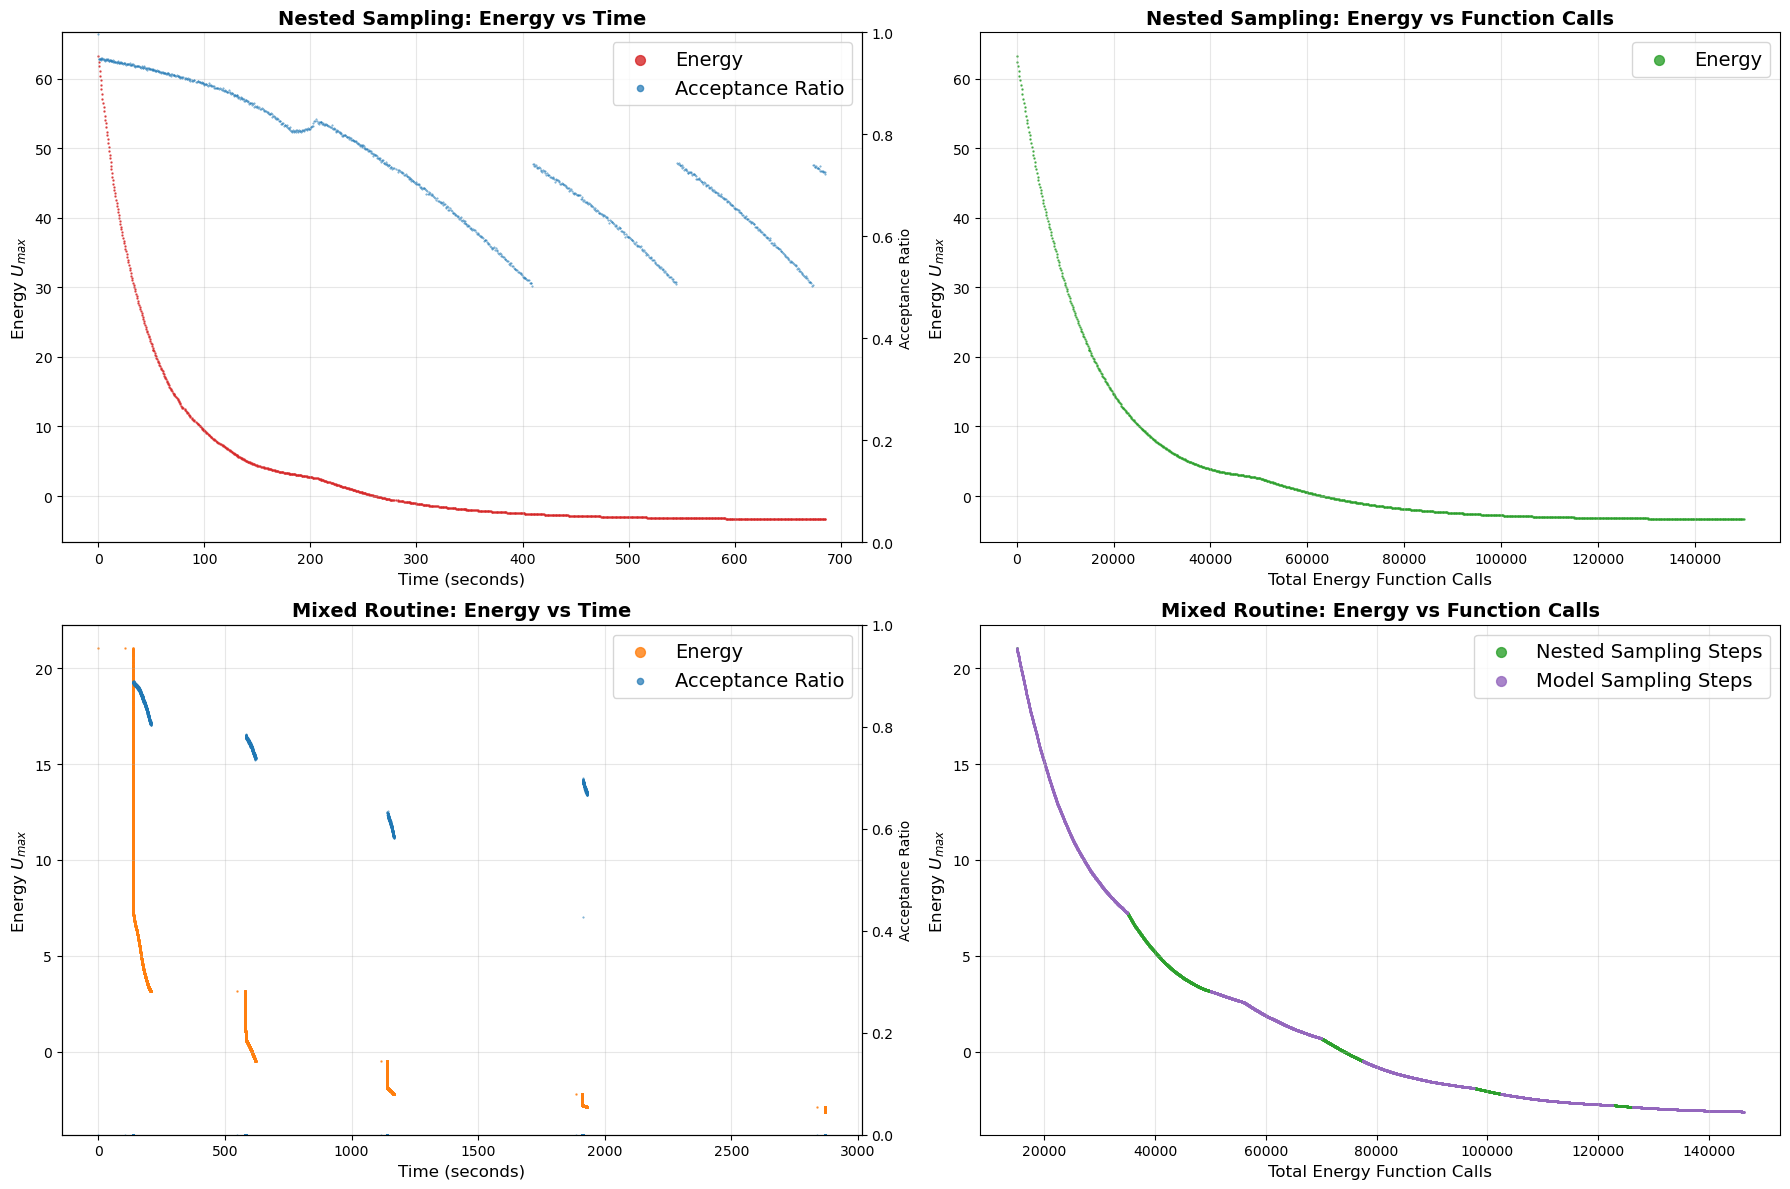

Saved side-by-side comparison to: ../resources/presentation/side_by_side_comparison.png


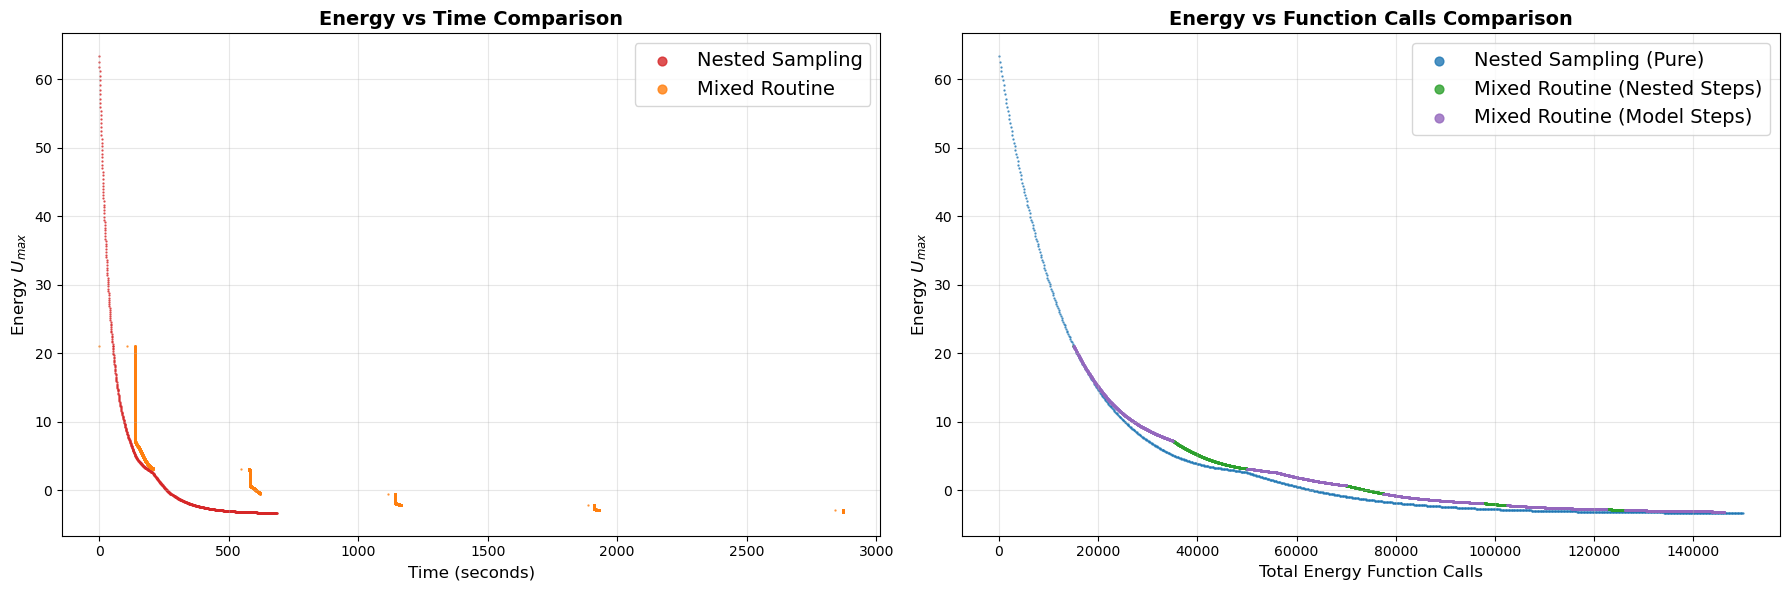


ALGORITHM COMPARISON SUMMARY

Metric                    Nested Sampling      Mixed Routine       
-----------------------------------------------------------------
Total Runtime (s)         685.69               2871.71             
Total Runtime (min)       11.43                47.86               
Total Energy Calls        1.50e+05             1.46e+05            
Initial Energy            63.35                21.06               
Final Energy              -3.31                -3.13               
Energy Reduction          66.66                24.18               
Energy Reduction/Time     0.0972               0.0084              
Energy Reduction/Call     0.000444             0.000165            



In [44]:
# Directories for both algorithms
nested_dir = "../resources/nested_sampling_configs/metrics/"
mixed_dir = "../resources/mixed_routine/all_live_samples/conditioned/metrics/"  # Adjust path as needed

try:
    # Load data from both algorithms
    nested_time_data, nested_calls_data = load_energy_data(nested_dir, "Nested Sampling")
    mixed_time_data, mixed_calls_data = load_energy_data(mixed_dir, "Mixed Routine")
    
    # Create comparison plots
    plot_algorithms_comparison(nested_time_data, nested_calls_data,
                             mixed_time_data, mixed_calls_data,
                             save_path="../resources/presentation/algorithms_comparison.png")
    
    plot_side_by_side_comparison(nested_time_data, nested_calls_data,
                               mixed_time_data, mixed_calls_data,
                               save_path="../resources/presentation/side_by_side_comparison.png")
    
    # Print comparative statistics
    print_comparison_summary(nested_time_data, nested_calls_data,
                           mixed_time_data, mixed_calls_data)
        
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Make sure both algorithms have been run and generated their data files.")